In [45]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback

In [46]:
env=gym.make("CartPole-v1")
eval_env=gym.make("CartPole-v1")

In [51]:
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/best_model",
    log_path="./logs/results",
    eval_freq=500,
    deterministic=True,
    render=False
)

In [52]:
model = stable_baselines3.PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=2.5e-4,
    n_steps=128,
    batch_size=32,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01,
)

model.learn(total_timesteps=10000,callback=eval_callback)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.3     |
|    ep_rew_mean     | 21.3     |
| time/              |          |
|    fps             | 306      |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 128      |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 22.7         |
|    ep_rew_mean          | 22.7         |
| time/                   |              |
|    fps                  | 180          |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 0.0025342326 |
|    clip_fraction        | 0.0453       |
|    clip_range           | 0.1          |
|    e

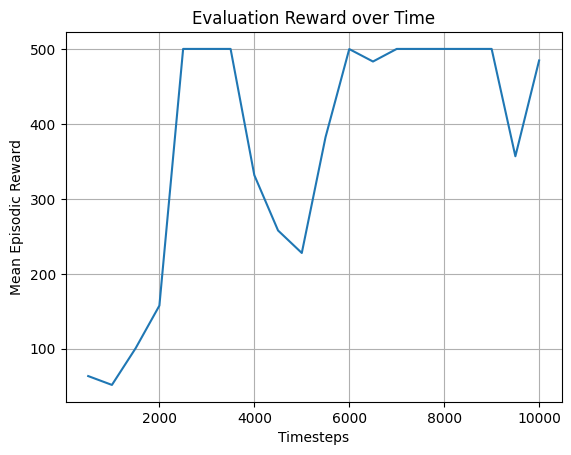

In [53]:
import os

# Load evaluation results
log_dir = "./logs/results"
evaluations = np.load(os.path.join(log_dir, "evaluations.npz"))

timesteps = evaluations["timesteps"]
mean_rewards = evaluations["results"].mean(axis=1)

# Plotting
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Episodic Reward")
plt.title("Evaluation Reward over Time")
plt.grid(True)
plt.show()